# Random Forest Model Training


## Load Cleaned Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clean_train = pd.read_csv('data/clean_train.csv')
clean_val = pd.read_csv('data/clean_val.csv')

X_tr = clean_train.drop(columns=['target'])
y_tr = clean_train['target']
X_val = clean_val.drop(columns=['target'])
y_val = clean_val['target']

print('X_tr shape:', X_tr.shape)
print('X_val shape:', X_val.shape)
print('y_tr shape:', y_tr.shape)
print('y_val shape:', y_val.shape)


## Target Skewness


Skewness: 2.09


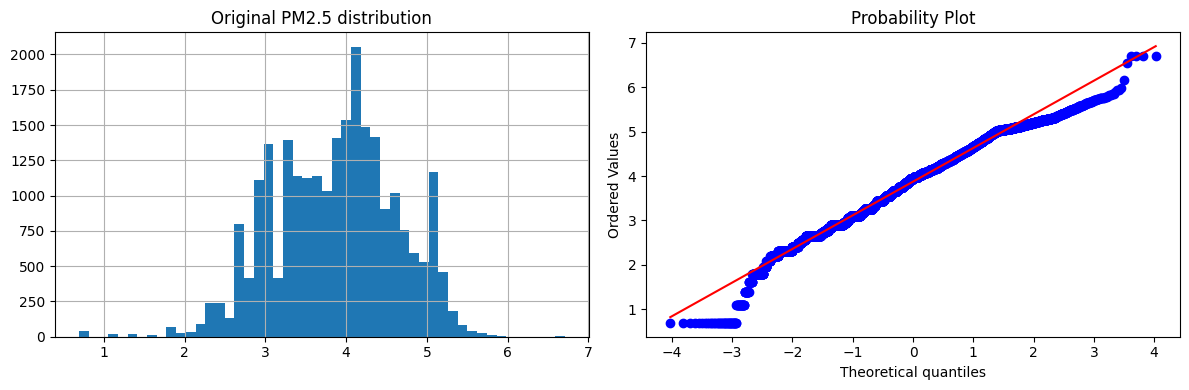

In [11]:
#Handle the target skewness by applying a log transform

import scipy.stats as stats

print(f"Skewness: {y_tr.skew():.2f}")



# Apply log transform
y_tr_log  = np.log1p(y_tr.reset_index(drop=True))
y_val_log = np.log1p(y_val.reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr_log.hist(bins=50, ax=axes[0])
axes[0].set_title("Original PM2.5 distribution")
stats.probplot(y_tr_log, plot=axes[1])
plt.tight_layout()
plt.show()


In [15]:
# Now we apply Randomforest Regressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Step 1 — feature selection using RF importance
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_tr, y_tr_log)

importance = pd.Series(rf_selector.feature_importances_, index=X_tr.columns)
top_features = importance.sort_values(ascending=False).head(15).index.tolist()

print("Top 15 features:")
print(importance.sort_values(ascending=False).head(15))

# Step 2 — select top features
X_tr_selected = X_tr[top_features]
X_val_selected = X_val[top_features]

# Step 3 — train final model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_tr_selected, y_tr_log)

# Step 4 — evaluate
y_val_pred = np.expm1(rf_model.predict(X_val_selected))  # reverse log transform
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"\nValidation RMSE: {rmse:.2f} µg/m³")


Top 15 features:
L3_AER_AI_sensor_altitude                          0.136147
L3_CO_CO_column_number_density                     0.106601
L3_HCHO_tropospheric_HCHO_column_number_density    0.056768
temperature_2m_above_ground                        0.047020
u_component_of_wind_10m_above_ground               0.046100
L3_NO2_NO2_column_number_density                   0.043247
v_component_of_wind_10m_above_ground               0.039213
L3_NO2_NO2_slant_column_number_density             0.033225
specific_humidity_2m_above_ground                  0.024635
L3_CLOUD_surface_albedo                            0.023569
relative_humidity_2m_above_ground                  0.022538
L3_NO2_tropopause_pressure                         0.021300
precipitable_water_entire_atmosphere               0.018408
L3_O3_O3_column_number_density                     0.017607
L3_O3_O3_effective_temperature                     0.017198
dtype: float64

Validation RMSE: 32.03 µg/m³


In [16]:
print(y_tr.describe())


count    24546.000000
mean        62.030995
std         47.960782
min          1.000000
25%         26.000000
50%         51.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64


In [17]:
mean_pm25 = y_tr.mean()
print(f"Mean PM2.5: {mean_pm25:.2f} µg/m³")
print(f"RMSE as % of mean: {(rmse / mean_pm25) * 100:.1f}%")


Mean PM2.5: 62.03 µg/m³
RMSE as % of mean: 51.6%
